# Machine Learning Workflow Demo

**Author:** Sasta12  
**Date:** 2026-02-22

This notebook demonstrates a typical machine learning workflow using Python, pandas, seaborn, matplotlib, and scikit-learn. We will use the classic Iris dataset for classification.

## 1. Import Required Libraries
We import libraries for data manipulation, visualization, and machine learning.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plot style
sns.set(style="whitegrid")

## 2. Load and Explore the Dataset
We will use the Iris dataset from seaborn. Let's load it and perform basic EDA.

In [2]:
# Load the Iris dataset
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Check for missing values and basic info
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
# Summary statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


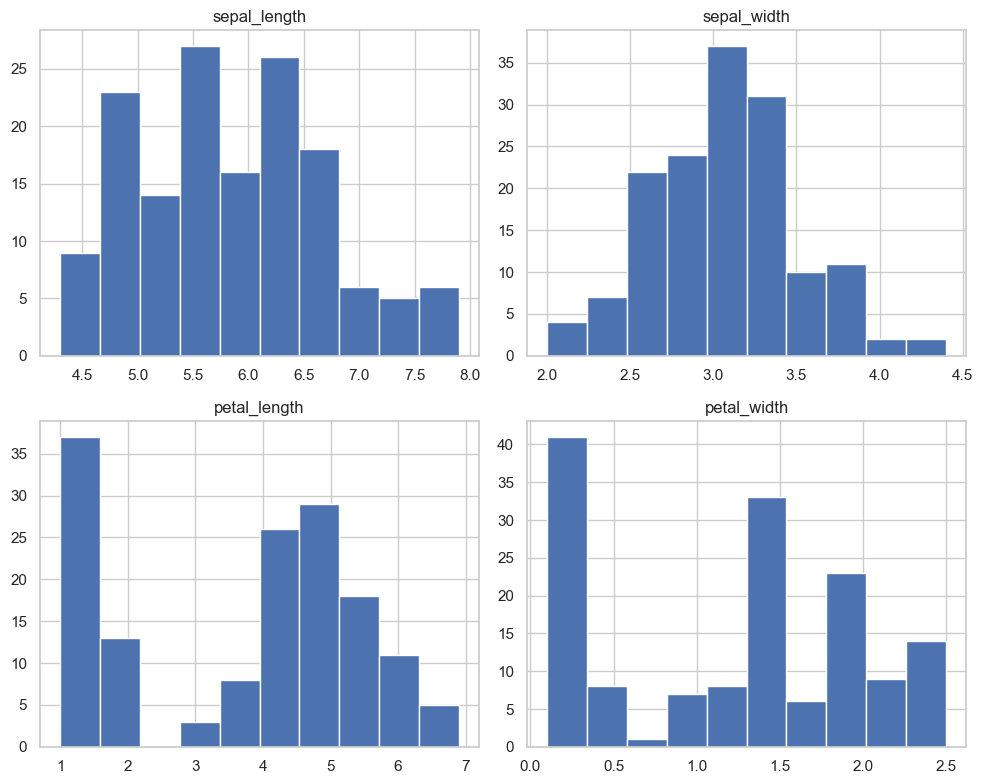

In [5]:
# Visualize distributions of numerical features
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [6]:
# Value counts for categorical feature
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Preprocess the Data
We will encode the target variable and scale the features.

In [7]:
# Encode the target variable
df["species_encoded"] = df["species"].astype("category").cat.codes

# Features and target
X = df.drop(["species", "species_encoded"], axis=1)
y = df["species_encoded"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show the first 5 rows of scaled features
pd.DataFrame(X_scaled, columns=X.columns).head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 4. Split Data into Training and Test Sets
We split the data for training and evaluation.

In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (120, 4), Test shape: (30, 4)


## 5. Train a Machine Learning Model
We will use Logistic Regression for classification.

In [9]:
# Train a logistic regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

## 6. Evaluate Model Performance
We evaluate the model using accuracy, confusion matrix, and classification report.

Test Accuracy: 0.93


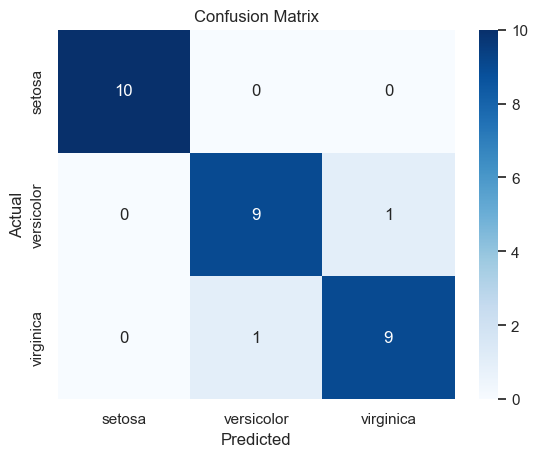

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [10]:
# Predict on the test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=df["species"].unique(),
    yticklabels=df["species"].unique(),
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=df["species"].unique()))

## 7. Make Predictions with the Model
Let's make predictions on new data (using a few test samples as an example).

In [11]:
# Predict on a few test samples
sample_idx = [0, 1, 2]
sample_X = X_test[sample_idx]
sample_true = y_test.iloc[sample_idx]
sample_pred = model.predict(sample_X)

print("True labels:", sample_true.values)
print("Predicted labels:", sample_pred)

True labels: [0 2 1]
Predicted labels: [0 2 1]


## Conclusion

In this notebook, we demonstrated a complete machine learning workflow: loading data, performing EDA, preprocessing, training a model, evaluating performance, and making predictions. This workflow can be adapted for other datasets and models as needed.